# GoldenCheetah 훈련 흐름 분석

가공된 자전거 라이드 데이터를 이용하여 주간·월간 훈련량의 변화를 확인한다.

## 1. 가공 데이터 불러오기

첫 번째 탐색 노트북에서 정리한 자전거 라이드 데이터를 불러오고 데이터프레임의 크기를 확인한다.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


project_root = Path("..").resolve()
processed_path = (
    project_root
    / "data"
    / "processed"
    / "goldencheetah_bike_rides_cleaned.csv"
)

rides_df = pd.read_csv(
    processed_path,
    parse_dates=["date"],
)

rides_df.shape

(592, 63)

## 2. 전체 기록 기간과 분포 확인

전체 날짜 범위와 연도·월별 라이드 수를 확인하여 기록이 연속적으로 존재하는지 살펴본다. 기록이 없는 기간은 실제 휴식이 아니라 데이터 누락일 수 있으므로, 훈련 흐름을 해석하기 전에 관측 범위를 먼저 확인한다.

In [3]:
rides_df["date"].agg(["min", "max"])

min   2005-06-25 14:26:00+00:00
max   2017-07-18 11:01:20+00:00
Name: date, dtype: datetime64[us, UTC]

In [4]:
rides_per_year = (
    rides_df["date"]
    .dt.year
    .value_counts()
    .sort_index()
)

rides_per_year

date
2005     21
2006     30
2007     71
2008     69
2009    144
2010     54
2011      2
2012     57
2013     10
2014     70
2015     44
2016     15
2017      5
Name: count, dtype: int64

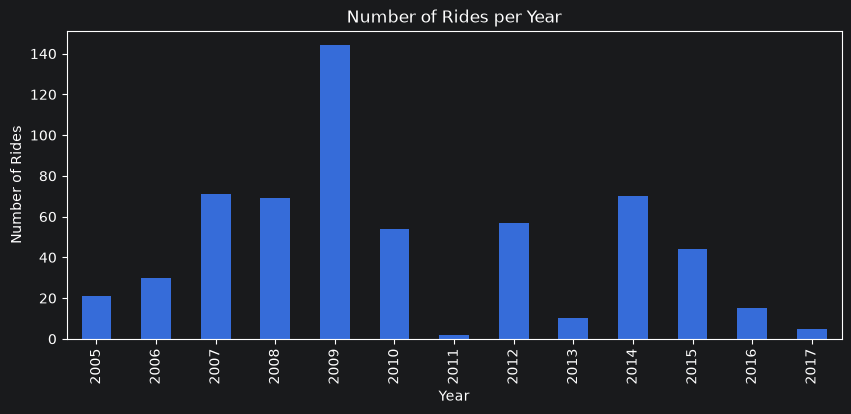

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

rides_per_year.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Number of Rides per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Rides")

plt.show()

In [6]:
monthly_ride_counts = (
    rides_df
    .set_index("date")
    .resample("MS")
    .size()
)

print("전체 월 수:", len(monthly_ride_counts))
print("라이드가 없는 월 수:", (monthly_ride_counts == 0).sum())

전체 월 수: 146
라이드가 없는 월 수: 70


In [7]:
active_months_per_year = (
    (monthly_ride_counts > 0)
    .groupby(monthly_ride_counts.index.year)
    .sum()
)

active_months_per_year

date
2005    7
2006    7
2007    9
2008    7
2009    9
2010    6
2011    2
2012    8
2013    2
2014    7
2015    7
2016    4
2017    1
dtype: int64

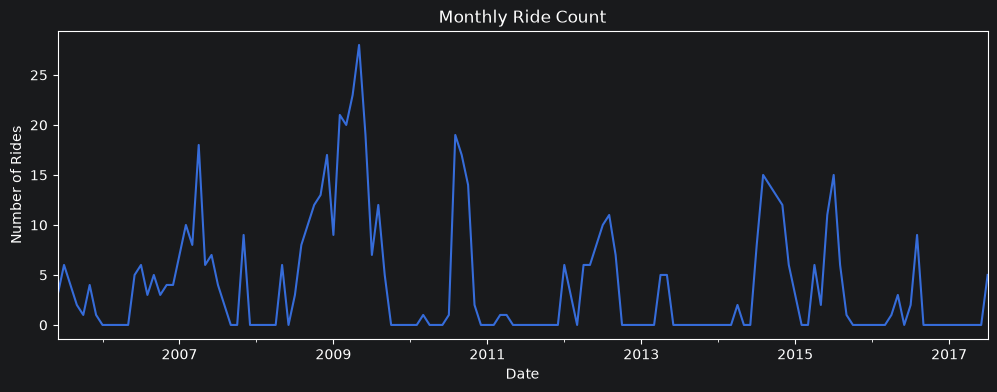

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

monthly_ride_counts.plot(
    ax=ax,
)

ax.set_title("Monthly Ride Count")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Rides")

plt.show()

In [9]:
busiest_months = monthly_ride_counts.nlargest(10)

busiest_months

date
2009-05-01 00:00:00+00:00    28
2009-04-01 00:00:00+00:00    23
2009-02-01 00:00:00+00:00    21
2009-03-01 00:00:00+00:00    20
2009-06-01 00:00:00+00:00    19
2010-08-01 00:00:00+00:00    19
2007-04-01 00:00:00+00:00    18
2008-12-01 00:00:00+00:00    17
2010-09-01 00:00:00+00:00    17
2014-08-01 00:00:00+00:00    15
dtype: int64

## 3. 훈련 흐름 분석 기간 선택

전체 데이터는 여러 시기에 나뉘어 기록되어 있다. 월별 라이드가 연속적으로 집중된 2009년 2월부터 6월까지를 후보 기간으로 선택하고, 운동 시간과 TSS가 분석 기준을 충족하는지 확인한다.

In [10]:
candidate_period_df = rides_df.loc[
    (rides_df["date"] >= "2009-02-01")
    & (rides_df["date"] < "2009-07-01")
].copy()

candidate_period_df.shape

(111, 63)

In [13]:
candidate_metric_usability_counts = candidate_period_df[
    [
        "workout_time_is_usable",
        "stored_tss_is_usable",
    ]
].sum()

candidate_metric_usability_counts

workout_time_is_usable    111
stored_tss_is_usable      111
dtype: int64

## 4. 주간 운동 시간과 TSS 분석

후보 기간을 실제 분석 기간으로 확정하고, 라이드 단위의 운동 시간과 TSS를 월요일부터 일요일까지의 주간 단위로 합산한다. 두 지표의 흐름과 상관관계를 비교하여 주간 훈련량과 전체 부하가 어떻게 움직이는지 확인한다.

In [15]:
analysis_period_df = candidate_period_df.copy()

weekly_workout_hours = (
    analysis_period_df
    .set_index("date")["workout_hours"]
    .resample("W-SUN")
    .sum()
)

weekly_workout_hours

date
2009-02-08 00:00:00+00:00     3.654167
2009-02-15 00:00:00+00:00     8.890000
2009-02-22 00:00:00+00:00    10.697500
2009-03-01 00:00:00+00:00     9.486111
2009-03-08 00:00:00+00:00     4.366111
2009-03-15 00:00:00+00:00     7.755322
2009-03-22 00:00:00+00:00    10.734444
2009-03-29 00:00:00+00:00     5.494444
2009-04-05 00:00:00+00:00    12.454167
2009-04-12 00:00:00+00:00     7.224856
2009-04-19 00:00:00+00:00     7.797222
2009-04-26 00:00:00+00:00    11.655000
2009-05-03 00:00:00+00:00    11.758333
2009-05-10 00:00:00+00:00    11.816667
2009-05-17 00:00:00+00:00     8.772500
2009-05-24 00:00:00+00:00    10.815833
2009-05-31 00:00:00+00:00    13.509444
2009-06-07 00:00:00+00:00     9.650278
2009-06-14 00:00:00+00:00    11.104444
2009-06-21 00:00:00+00:00     7.973333
2009-06-28 00:00:00+00:00     5.209444
Freq: W-SUN, Name: workout_hours, dtype: float64

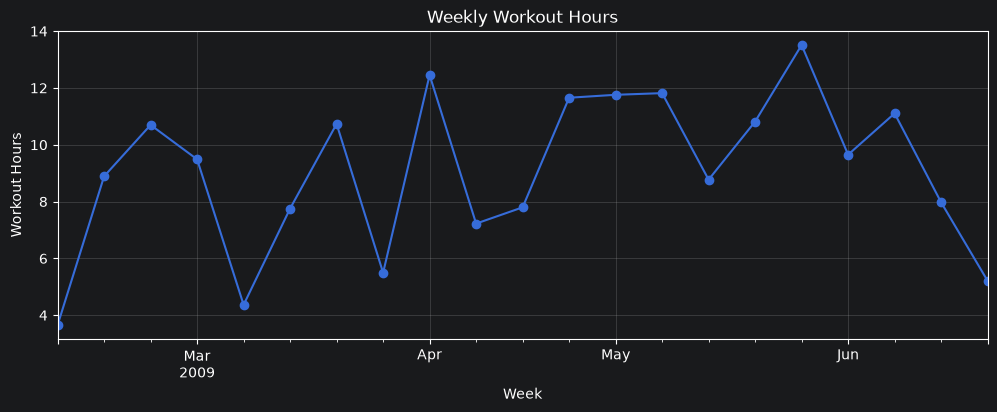

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

weekly_workout_hours.plot(
    ax=ax,
    marker="o",
)

ax.set_title("Weekly Workout Hours")
ax.set_xlabel("Week")
ax.set_ylabel("Workout Hours")
ax.grid(alpha=0.3)

plt.show()

In [17]:
weekly_tss = (
    analysis_period_df
    .set_index("date")["coggan_tss"]
    .resample("W-SUN")
    .sum()
)

weekly_tss

date
2009-02-08 00:00:00+00:00    287.77627
2009-02-15 00:00:00+00:00    604.74247
2009-02-22 00:00:00+00:00    718.64125
2009-03-01 00:00:00+00:00    662.71390
2009-03-08 00:00:00+00:00    348.76627
2009-03-15 00:00:00+00:00    594.12925
2009-03-22 00:00:00+00:00    812.03838
2009-03-29 00:00:00+00:00    458.53591
2009-04-05 00:00:00+00:00    854.20816
2009-04-12 00:00:00+00:00    424.45406
2009-04-19 00:00:00+00:00    605.44146
2009-04-26 00:00:00+00:00    928.96723
2009-05-03 00:00:00+00:00    848.24929
2009-05-10 00:00:00+00:00    716.12711
2009-05-17 00:00:00+00:00    665.29280
2009-05-24 00:00:00+00:00    717.04035
2009-05-31 00:00:00+00:00    965.65066
2009-06-07 00:00:00+00:00    675.71416
2009-06-14 00:00:00+00:00    831.27619
2009-06-21 00:00:00+00:00    548.72505
2009-06-28 00:00:00+00:00    398.77081
Freq: W-SUN, Name: coggan_tss, dtype: float64

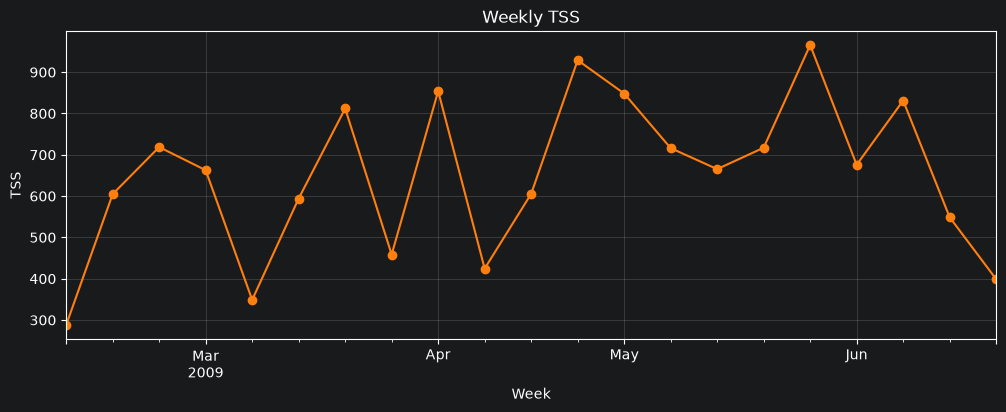

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

weekly_tss.plot(
    ax=ax,
    marker="o",
    color="tab:orange",
)

ax.set_title("Weekly TSS")
ax.set_xlabel("Week")
ax.set_ylabel("TSS")
ax.grid(alpha=0.3)

plt.show()

In [19]:
workout_hours_tss_correlation = weekly_workout_hours.corr(
    weekly_tss
)

workout_hours_tss_correlation

np.float64(0.9618920055718075)

## 5. 주간 부하 밀도 분석

주간 운동 시간과 TSS를 하나의 데이터프레임으로 정리한다. 시간당 TSS를 계산하여 총 TSS의 변화가 운동 시간과 부하 밀도 중 어느 요소의 영향을 받았는지 비교한다.

In [23]:
weekly_training_df = pd.DataFrame(
    {
        "workout_hours": weekly_workout_hours,
        "tss": weekly_tss,
    }
)

weekly_training_df

,workout_hours,tss
date,,
2009-02-08 00:00:00+00:00,3.654167,287.77627
2009-02-15 00:00:00+00:00,8.890000,604.74247
2009-02-22 00:00:00+00:00,10.697500,718.64125
2009-03-01 00:00:00+00:00,9.486111,662.71390
2009-03-08 00:00:00+00:00,4.366111,348.76627
2009-03-15 00:00:00+00:00,7.755322,594.12925
2009-03-22 00:00:00+00:00,10.734444,812.03838
2009-03-29 00:00:00+00:00,5.494444,458.53591
2009-04-05 00:00:00+00:00,12.454167,854.20816


In [31]:
weekly_training_df["tss_per_hour"] = (
    weekly_training_df["tss"]
    / weekly_training_df["workout_hours"]
)

weekly_training_df.round(2)

,workout_hours,tss,tss_per_hour
date,,,
2009-02-08 00:00:00+00:00,3.65,287.78,78.75
2009-02-15 00:00:00+00:00,8.89,604.74,68.03
2009-02-22 00:00:00+00:00,10.70,718.64,67.18
2009-03-01 00:00:00+00:00,9.49,662.71,69.86
2009-03-08 00:00:00+00:00,4.37,348.77,79.88
2009-03-15 00:00:00+00:00,7.76,594.13,76.61
2009-03-22 00:00:00+00:00,10.73,812.04,75.65
2009-03-29 00:00:00+00:00,5.49,458.54,83.45
2009-04-05 00:00:00+00:00,12.45,854.21,68.59


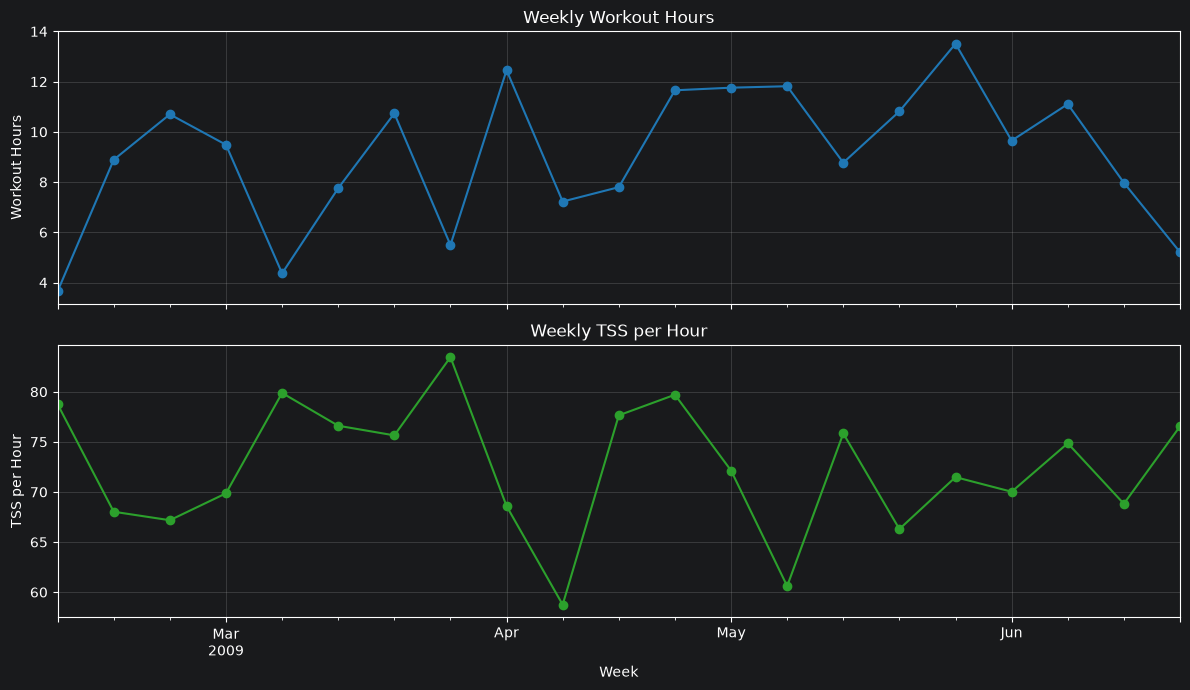

In [33]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 7),
    sharex=True,
)

weekly_training_df["workout_hours"].plot(
    ax=axes[0],
    marker="o",
    color="tab:blue",
)

axes[0].set_title("Weekly Workout Hours")
axes[0].set_ylabel("Workout Hours")
axes[0].grid(alpha=0.3)

weekly_training_df["tss_per_hour"].plot(
    ax=axes[1],
    marker="o",
    color="tab:green",
)

axes[1].set_title("Weekly TSS per Hour")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("TSS per Hour")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 최근 4주 훈련 부하 분석

주간 TSS의 큰 변동을 완화하여 누적 흐름을 보기 위해 4주 이동평균을 계산한다. 흐름을 나타내는 현재 주 포함 이동평균과 현재 주의 상대적 부하를 판단하기 위한 이전 4주 평균을 구분한다.

In [36]:
weekly_training_df["tss_4_week_average"] = (
    weekly_training_df["tss"]
    .rolling(window=4)
    .mean()
)

weekly_training_df.round(2)

,workout_hours,tss,tss_per_hour,tss_4_week_average
date,,,,
2009-02-08 00:00:00+00:00,3.65,287.78,78.75,NaN
2009-02-15 00:00:00+00:00,8.89,604.74,68.03,NaN
2009-02-22 00:00:00+00:00,10.70,718.64,67.18,NaN
2009-03-01 00:00:00+00:00,9.49,662.71,69.86,568.47
2009-03-08 00:00:00+00:00,4.37,348.77,79.88,583.72
2009-03-15 00:00:00+00:00,7.76,594.13,76.61,581.06
2009-03-22 00:00:00+00:00,10.73,812.04,75.65,604.41
2009-03-29 00:00:00+00:00,5.49,458.54,83.45,553.37
2009-04-05 00:00:00+00:00,12.45,854.21,68.59,679.73


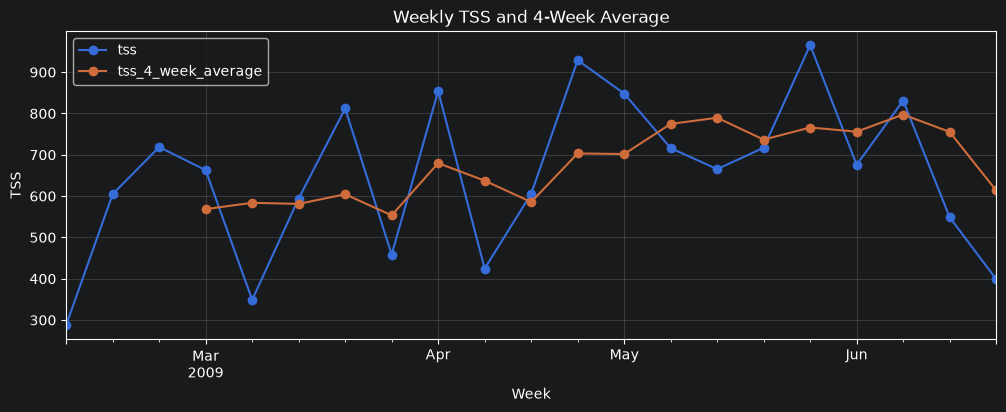

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))

weekly_training_df[
    [
        "tss",
        "tss_4_week_average",
    ]
].plot(
    ax=ax,
    marker="o",
)

ax.set_title("Weekly TSS and 4-Week Average")
ax.set_xlabel("Week")
ax.set_ylabel("TSS")
ax.grid(alpha=0.3)

plt.show()

In [38]:
weekly_training_df["previous_4_week_tss_average"] = (
    weekly_training_df["tss"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

weekly_training_df.round(2)

,workout_hours,tss,tss_per_hour,tss_4_week_average,previous_4_week_tss_average
date,,,,,
2009-02-08 00:00:00+00:00,3.65,287.78,78.75,NaN,NaN
2009-02-15 00:00:00+00:00,8.89,604.74,68.03,NaN,NaN
2009-02-22 00:00:00+00:00,10.70,718.64,67.18,NaN,NaN
2009-03-01 00:00:00+00:00,9.49,662.71,69.86,568.47,NaN
2009-03-08 00:00:00+00:00,4.37,348.77,79.88,583.72,568.47
2009-03-15 00:00:00+00:00,7.76,594.13,76.61,581.06,583.72
2009-03-22 00:00:00+00:00,10.73,812.04,75.65,604.41,581.06
2009-03-29 00:00:00+00:00,5.49,458.54,83.45,553.37,604.41
2009-04-05 00:00:00+00:00,12.45,854.21,68.59,679.73,553.37


In [39]:
weekly_training_df["tss_vs_previous_4_week_average_ratio"] = (
    weekly_training_df["tss"]
    / weekly_training_df["previous_4_week_tss_average"]
)

weekly_training_df.round(2)

,workout_hours,tss,tss_per_hour,tss_4_week_average,previous_4_week_tss_average,tss_vs_previous_4_week_average_ratio
date,,,,,,
2009-02-08 00:00:00+00:00,3.65,287.78,78.75,NaN,NaN,NaN
2009-02-15 00:00:00+00:00,8.89,604.74,68.03,NaN,NaN,NaN
2009-02-22 00:00:00+00:00,10.70,718.64,67.18,NaN,NaN,NaN
2009-03-01 00:00:00+00:00,9.49,662.71,69.86,568.47,NaN,NaN
2009-03-08 00:00:00+00:00,4.37,348.77,79.88,583.72,568.47,0.61
2009-03-15 00:00:00+00:00,7.76,594.13,76.61,581.06,583.72,1.02
2009-03-22 00:00:00+00:00,10.73,812.04,75.65,604.41,581.06,1.40
2009-03-29 00:00:00+00:00,5.49,458.54,83.45,553.37,604.41,0.76
2009-04-05 00:00:00+00:00,12.45,854.21,68.59,679.73,553.37,1.54


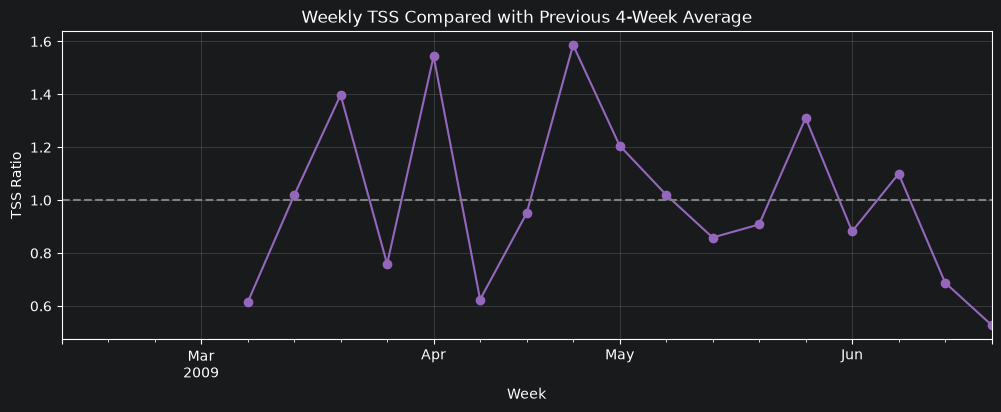

In [40]:
fig, ax = plt.subplots(figsize=(12, 4))

weekly_training_df[
    "tss_vs_previous_4_week_average_ratio"
].plot(
    ax=ax,
    marker="o",
    color="tab:purple",
)

ax.axhline(
    y=1.0,
    color="gray",
    linestyle="--",
)

ax.set_title("Weekly TSS Compared with Previous 4-Week Average")
ax.set_xlabel("Week")
ax.set_ylabel("TSS Ratio")
ax.grid(alpha=0.3)

plt.show()

In [41]:
weekly_training_df.loc[
    "2009-03-08":"2009-04-26",
    [
        "workout_hours",
        "tss",
        "tss_per_hour",
        "previous_4_week_tss_average",
        "tss_vs_previous_4_week_average_ratio",
    ],
].round(2)

,workout_hours,tss,tss_per_hour,previous_4_week_tss_average,tss_vs_previous_4_week_average_ratio
date,,,,,
2009-03-08 00:00:00+00:00,4.37,348.77,79.88,568.47,0.61
2009-03-15 00:00:00+00:00,7.76,594.13,76.61,583.72,1.02
2009-03-22 00:00:00+00:00,10.73,812.04,75.65,581.06,1.40
2009-03-29 00:00:00+00:00,5.49,458.54,83.45,604.41,0.76
2009-04-05 00:00:00+00:00,12.45,854.21,68.59,553.37,1.54
2009-04-12 00:00:00+00:00,7.22,424.45,58.75,679.73,0.62
2009-04-19 00:00:00+00:00,7.80,605.44,77.65,637.31,0.95
2009-04-26 00:00:00+00:00,11.66,928.97,79.71,585.66,1.59


### 주간 훈련 부하 분석 결과

- 전체 데이터는 2005년부터 2017년까지 존재하지만 월별 기록 공백이 많아 13년의 연속적인 훈련 기록으로 해석하기 어렵다.
- 2009년 2월부터 6월까지는 111개의 라이드가 비교적 연속적으로 존재하며, 운동 시간과 저장된 TSS가 모두 현재 분석 기준을 충족한다.
- 선택한 기간에는 21주 연속으로 운동 기록이 존재한다.
- 주간 운동 시간과 TSS의 상관계수는 약 0.96으로, 이 기간의 총 TSS 변화는 운동 시간의 영향을 크게 받는다.
- 시간당 TSS를 함께 비교하면 짧지만 부하 밀도가 높은 주와 길지만 부하 밀도가 낮은 주를 구분할 수 있다.
- 이전 4주 평균 대비 현재 TSS 비율은 평소와 비교한 주간 부하를 나타내지만, 이 값만으로 회복 주나 고강도 훈련을 확정하지 않는다.

## 7. 주간 훈련 빈도와 일별 기록 준비

같은 주간 운동 시간과 TSS도 라이드 횟수와 활동 날짜의 배치에 따라 다르게 구성될 수 있다. 주간 라이드 횟수, 라이드당 평균 운동 시간, 기록상 활동 날짜 수를 계산하고, 이후 연속 운동일과 무기록 간격을 분석하기 위한 일별 데이터프레임을 만든다.

In [42]:
weekly_training_df["ride_count"] = (
    analysis_period_df
    .set_index("date")
    .resample("W-SUN")
    .size()
)

weekly_training_df[
    [
        "workout_hours",
        "tss",
        "ride_count",
    ]
]

,workout_hours,tss,ride_count
date,,,
2009-02-08 00:00:00+00:00,3.654167,287.77627,2
2009-02-15 00:00:00+00:00,8.890000,604.74247,9
2009-02-22 00:00:00+00:00,10.697500,718.64125,6
2009-03-01 00:00:00+00:00,9.486111,662.71390,5
2009-03-08 00:00:00+00:00,4.366111,348.76627,3
2009-03-15 00:00:00+00:00,7.755322,594.12925,6
2009-03-22 00:00:00+00:00,10.734444,812.03838,6
2009-03-29 00:00:00+00:00,5.494444,458.53591,3
2009-04-05 00:00:00+00:00,12.454167,854.20816,5


In [43]:
weekly_training_df["average_hours_per_ride"] = (
    weekly_training_df["workout_hours"]
    / weekly_training_df["ride_count"]
)

weekly_training_df[
    [
        "ride_count",
        "workout_hours",
        "average_hours_per_ride",
        "tss",
    ]
].round(2)

,ride_count,workout_hours,average_hours_per_ride,tss
date,,,,
2009-02-08 00:00:00+00:00,2,3.65,1.83,287.78
2009-02-15 00:00:00+00:00,9,8.89,0.99,604.74
2009-02-22 00:00:00+00:00,6,10.70,1.78,718.64
2009-03-01 00:00:00+00:00,5,9.49,1.90,662.71
2009-03-08 00:00:00+00:00,3,4.37,1.46,348.77
2009-03-15 00:00:00+00:00,6,7.76,1.29,594.13
2009-03-22 00:00:00+00:00,6,10.73,1.79,812.04
2009-03-29 00:00:00+00:00,3,5.49,1.83,458.54
2009-04-05 00:00:00+00:00,5,12.45,2.49,854.21


In [44]:
analysis_period_df["ride_day"] = (
    analysis_period_df["date"]
    .dt.normalize()
)

analysis_period_df[
    [
        "date",
        "ride_day",
    ]
].head()

,date,ride_day
200,2009-02-07 11:38:22+00:00,2009-02-07 00:00:00+00:00
201,2009-02-08 12:19:52+00:00,2009-02-08 00:00:00+00:00
202,2009-02-10 18:00:00+00:00,2009-02-10 00:00:00+00:00
203,2009-02-11 18:00:00+00:00,2009-02-11 00:00:00+00:00
204,2009-02-12 00:00:00+00:00,2009-02-12 00:00:00+00:00


In [45]:
weekly_training_df["active_day_count"] = (
    analysis_period_df
    .set_index("date")["ride_day"]
    .resample("W-SUN")
    .nunique()
)

weekly_training_df[
    [
        "ride_count",
        "active_day_count",
        "workout_hours",
        "tss",
    ]
]

,ride_count,active_day_count,workout_hours,tss
date,,,,
2009-02-08 00:00:00+00:00,2,2,3.654167,287.77627
2009-02-15 00:00:00+00:00,9,6,8.890000,604.74247
2009-02-22 00:00:00+00:00,6,4,10.697500,718.64125
2009-03-01 00:00:00+00:00,5,4,9.486111,662.71390
2009-03-08 00:00:00+00:00,3,3,4.366111,348.76627
2009-03-15 00:00:00+00:00,6,4,7.755322,594.12925
2009-03-22 00:00:00+00:00,6,5,10.734444,812.03838
2009-03-29 00:00:00+00:00,3,3,5.494444,458.53591
2009-04-05 00:00:00+00:00,5,5,12.454167,854.20816


In [46]:
weekly_training_df["no_ride_day_count"] = (
    7 - weekly_training_df["active_day_count"]
)

weekly_training_df[
    [
        "ride_count",
        "active_day_count",
        "no_ride_day_count",
        "workout_hours",
        "tss",
    ]
]

,ride_count,active_day_count,no_ride_day_count,workout_hours,tss
date,,,,,
2009-02-08 00:00:00+00:00,2,2,5,3.654167,287.77627
2009-02-15 00:00:00+00:00,9,6,1,8.890000,604.74247
2009-02-22 00:00:00+00:00,6,4,3,10.697500,718.64125
2009-03-01 00:00:00+00:00,5,4,3,9.486111,662.71390
2009-03-08 00:00:00+00:00,3,3,4,4.366111,348.76627
2009-03-15 00:00:00+00:00,6,4,3,7.755322,594.12925
2009-03-22 00:00:00+00:00,6,5,2,10.734444,812.03838
2009-03-29 00:00:00+00:00,3,3,4,5.494444,458.53591
2009-04-05 00:00:00+00:00,5,5,2,12.454167,854.20816


In [48]:
daily_training_df = (
    analysis_period_df
    .set_index("date")
    .resample("D")
    .agg(
        workout_hours=("workout_hours", "sum"),
        tss=("coggan_tss", "sum"),
        ride_count=("sport", "size"),
    )
)

daily_training_df.head(10)

,workout_hours,tss,ride_count
date,,,
2009-02-07 00:00:00+00:00,1.193333,111.22867,1
2009-02-08 00:00:00+00:00,2.460833,176.54760,1
2009-02-09 00:00:00+00:00,0.000000,0.00000,0
2009-02-10 00:00:00+00:00,0.833333,43.90424,1
2009-02-11 00:00:00+00:00,1.000000,50.11669,1
2009-02-12 00:00:00+00:00,2.000000,100.23338,2
2009-02-13 00:00:00+00:00,1.124167,108.21922,1
2009-02-14 00:00:00+00:00,1.970278,116.20702,3
2009-02-15 00:00:00+00:00,1.962222,186.06192,1


In [51]:
daily_training_df["has_recorded_ride"] = (
    daily_training_df["ride_count"] > 0
)

daily_training_df["has_recorded_ride"].value_counts()

has_recorded_ride
True     93
False    49
Name: count, dtype: int64

In [52]:
daily_date_index = pd.date_range(
    start=weekly_training_df.index.min() - pd.Timedelta(days=6),
    end=weekly_training_df.index.max(),
    freq="D",
)

daily_training_df = daily_training_df.reindex(
    daily_date_index,
    fill_value=0,
)

daily_training_df.index.name = "date"

daily_training_df["has_recorded_ride"] = (
    daily_training_df["ride_count"] > 0
)

daily_training_df["has_recorded_ride"].value_counts()

has_recorded_ride
True     93
False    54
Name: count, dtype: int64

### 주간 훈련 빈도 분석 결과

- 라이드 횟수와 실제로 라이드가 기록된 날짜 수는 서로 다르며, 같은 날 여러 라이드가 기록된 경우가 있다.
- 주간 운동 시간과 TSS가 높더라도 적은 날짜에 부하가 집중되거나 여러 날짜에 분산될 수 있다.
- `no_ride_day_count`는 실제 휴식을 확정하는 값이 아니라 라이드가 기록되지 않은 날짜 수이다.
- 주간 데이터와 일별 데이터의 범위를 2009년 2월 2일부터 6월 28일까지 21주로 맞췄다. 전체 147일 중 라이드 기록이 있는 날은 93일, 기록이 없는 날은 54일이다.
- 다음 단계에서는 일별 기록 여부를 이용하여 연속 운동일과 연속 무기록일을 분석한다.